# 01 — Exploration des données & Collecte

**Objectif** : comprendre les données StatsBomb, collecter une première saison, et valider le pipeline.

## Checklist de cette étape
- [ ] Vérifier que `statsbombpy` fonctionne
- [ ] Lister les compétitions disponibles
- [ ] Collecter une saison complète
- [ ] Explorer manuellement 5 matchs
- [ ] Nettoyer les données
- [ ] Valider avec le rapport de qualité
- [ ] Sauvegarder le dataset propre

In [2]:
# Setup : ajouter le dossier parent au path pour importer src/
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Style des graphiques
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.figsize': (12, 6),
    'figure.dpi': 100
})

print('Setup OK ✓')

Setup OK ✓


---
## 1. Vérification de StatsBomb

In [3]:
from statsbombpy import sb

# Test rapide
comps = sb.competitions()
print(f"Nombre de compétitions disponibles : {len(comps)}")
print(f"Colonnes : {list(comps.columns)}")
print()
comps[['competition_id', 'season_id', 'competition_name', 'season_name']].head(20)

/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Nombre de compétitions disponibles : 75
Colonnes : ['competition_id', 'season_id', 'country_name', 'competition_name', 'competition_gender', 'competition_youth', 'competition_international', 'season_name', 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']



,competition_id,season_id,competition_name,season_name
0,9,281,1. Bundesliga,2023/2024
1,9,27,1. Bundesliga,2015/2016
2,1267,107,African Cup of Nations,2023
3,16,4,Champions League,2018/2019
4,16,1,Champions League,2017/2018
5,16,2,Champions League,2016/2017
6,16,27,Champions League,2015/2016
7,16,26,Champions League,2014/2015
8,16,25,Champions League,2013/2014
9,16,24,Champions League,2012/2013


In [4]:
# Voir toutes les compétitions uniques
print("Compétitions disponibles :\n")
for _, row in comps.groupby('competition_name').first().iterrows():
    n_seasons = len(comps[comps['competition_name'] == row.name])
    print(f"  {row.name} (id={row['competition_id']}) — {n_seasons} saison(s)")

Compétitions disponibles :

  1. Bundesliga (id=9) — 2 saison(s)
  African Cup of Nations (id=1267) — 1 saison(s)
  Champions League (id=16) — 18 saison(s)
  Copa America (id=223) — 1 saison(s)
  Copa del Rey (id=87) — 3 saison(s)
  FA Women's Super League (id=37) — 3 saison(s)
  FIFA U20 World Cup (id=1470) — 1 saison(s)
  FIFA World Cup (id=43) — 8 saison(s)
  Indian Super league (id=1238) — 1 saison(s)
  La Liga (id=11) — 18 saison(s)
  Liga Profesional (id=81) — 2 saison(s)
  Ligue 1 (id=7) — 3 saison(s)
  Major League Soccer (id=44) — 1 saison(s)
  NWSL (id=49) — 1 saison(s)
  North American League (id=116) — 1 saison(s)
  Premier League (id=2) — 2 saison(s)
  Serie A (id=12) — 2 saison(s)
  UEFA Euro (id=55) — 2 saison(s)
  UEFA Europa League (id=35) — 1 saison(s)
  UEFA Women's Euro (id=53) — 2 saison(s)
  Women's World Cup (id=72) — 2 saison(s)


---
## 2. Choisir une compétition de départ

On commence par **une seule saison** pour prototyper le pipeline.
La Liga et la Champions League sont généralement les plus complètes dans StatsBomb Open Data.

In [5]:
# Voir les saisons disponibles pour La Liga
la_liga = comps[comps['competition_name'].str.contains('Liga', case=False, na=False)]
print("La Liga — saisons disponibles :")
la_liga[['competition_id', 'season_id', 'season_name']].sort_values('season_id')

La Liga — saisons disponibles :


,competition_id,season_id,season_name
41,11,1,2017/2018
42,11,2,2016/2017
40,11,4,2018/2019
49,11,21,2009/2010
48,11,22,2010/2011
47,11,23,2011/2012
46,11,24,2012/2013
45,11,25,2013/2014
44,11,26,2014/2015
1,9,27,2015/2016


In [7]:
# Choisir une saison — MODIFIER ICI si besoin
COMPETITION_ID = 11   # La Liga (vérifier avec la cellule précédente)
SEASON_ID = 90        # Vérifier le season_id qui correspond

# Vérifier
chosen = comps[(comps['competition_id'] == COMPETITION_ID) & 
               (comps['season_id'] == SEASON_ID)]
if len(chosen) == 0:
    print("⚠️  Compétition/saison non trouvée ! Vérifier les IDs.")
    print("Compétitions avec le bon competition_id :")
    print(comps[comps['competition_id'] == COMPETITION_ID][['season_id', 'season_name']])
else:
    print(f"✓ Sélection : {chosen.iloc[0]['competition_name']} — {chosen.iloc[0]['season_name']}")

✓ Sélection : La Liga — 2020/2021


In [8]:
# Lister les matchs
matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"Nombre de matchs : {len(matches)}")
print(f"Colonnes : {list(matches.columns)}")
matches.head()

/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Nombre de matchs : 35
Colonnes : ['match_id', 'match_date', 'kick_off', 'competition', 'season', 'home_team', 'away_team', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_stage', 'stadium', 'referee', 'home_managers', 'away_managers', 'data_version', 'shot_fidelity_version', 'xy_fidelity_version']


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,available,2023-07-25T03:54:59.280826,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2
1,3773565,2021-01-09,18:30:00.000,Spain - La Liga,2020/2021,Granada,Barcelona,0,4,available,available,2023-07-25T03:51:37.437064,2023-07-25T04:30:16.058384,18,Regular Season,Estadio Nuevo Los Cármenes,Ricardo De Burgos Bengoetxea,Diego Martínez Penas,Ronald Koeman,1.1.0,2,2
2,3773457,2021-05-16,18:30:00.000,Spain - La Liga,2020/2021,Barcelona,Celta Vigo,1,2,available,available,2022-12-02T09:26:39.496362,2023-04-27T23:03:53.506485,37,Regular Season,Spotify Camp Nou,NaN,Ronald Koeman,Eduardo Germán Coudet,1.1.0,2,2
3,3773631,2021-02-07,21:00:00.000,Spain - La Liga,2020/2021,Real Betis,Barcelona,2,3,available,available,2023-07-25T03:47:44.278651,2023-07-25T03:56:34.733180,22,Regular Season,Estadio Benito Villamarín,NaN,Manuel Luis Pellegrini Ripamonti,Ronald Koeman,1.1.0,2,2
4,3773665,2021-03-06,21:00:00.000,Spain - La Liga,2020/2021,Osasuna,Barcelona,0,2,available,available,2022-12-02T08:46:42.897589,2023-04-28T02:57:03.412841,26,Regular Season,Estadio El Sadar,Guillermo Cuadra Fernández,Jagoba Arrasate Elustondo,Ronald Koeman,1.1.0,2,2


---
## 3. Explorer un match en détail

Avant d'automatiser, on regarde manuellement les événements d'un match.

In [9]:
# Prendre le premier match
sample_match_id = matches.iloc[0]['match_id']
sample_home = matches.iloc[0]['home_team']
sample_away = matches.iloc[0]['away_team']
print(f"Match : {sample_home} vs {sample_away} (id={sample_match_id})")

# Télécharger les événements
events = sb.events(match_id=sample_match_id)
print(f"\nNombre d'événements : {len(events)}")
print(f"Types d'événements : {events['type'].value_counts().to_dict()}")

Match : Deportivo Alavés vs Barcelona (id=3773386)


/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(



Nombre d'événements : 3891
Types d'événements : {'Pass': 1118, 'Ball Receipt*': 1059, 'Carry': 888, 'Pressure': 307, 'Ball Recovery': 99, 'Duel': 63, 'Dribble': 40, 'Clearance': 39, 'Block': 39, 'Goal Keeper': 35, 'Dispossessed': 29, 'Shot': 29, 'Foul Won': 26, 'Miscontrol': 26, 'Dribbled Past': 26, 'Foul Committed': 26, 'Interception': 14, 'Substitution': 10, 'Half Start': 4, 'Half End': 4, 'Starting XI': 2, 'Referee Ball-Drop': 2, '50/50': 2, 'Bad Behaviour': 1, 'Injury Stoppage': 1, 'Error': 1, 'Tactical Shift': 1}


In [10]:
# Filtrer les tirs
shots_sample = events[events['type'] == 'Shot'].copy()
print(f"Tirs dans ce match : {len(shots_sample)}")
print(f"\nColonnes liées aux tirs :")
shot_cols = [c for c in shots_sample.columns if 'shot' in c.lower() or c in ['team', 'player', 'minute', 'second', 'type']]
print(shot_cols)
print()

# Afficher les tirs avec les champs clés
display_cols = ['minute', 'second', 'team', 'player', 'shot_statsbomb_xg', 
                'shot_outcome', 'shot_type', 'shot_body_part']
display_cols = [c for c in display_cols if c in shots_sample.columns]
shots_sample[display_cols]

Tirs dans ce match : 29

Colonnes liées aux tirs :
['minute', 'pass_assisted_shot_id', 'pass_shot_assist', 'player', 'second', 'shot_aerial_won', 'shot_body_part', 'shot_end_location', 'shot_first_time', 'shot_freeze_frame', 'shot_key_pass_id', 'shot_one_on_one', 'shot_open_goal', 'shot_outcome', 'shot_statsbomb_xg', 'shot_technique', 'shot_type', 'team', 'type']



,minute,second,team,player,shot_statsbomb_xg,shot_outcome,shot_type,shot_body_part
3805,12,19,Barcelona,Anssumane Fati,0.200969,Off T,Open Play,Right Foot
3806,16,7,Deportivo Alavés,Edgar Antonio Méndez Ortega,0.096384,Saved,Open Play,Right Foot
3807,19,42,Barcelona,Antoine Griezmann,0.098879,Off T,Open Play,Left Foot
3808,22,26,Barcelona,Lionel Andrés Messi Cuccittini,0.078938,Blocked,Free Kick,Left Foot
3809,30,6,Deportivo Alavés,Luis Jesús Rioja González,0.976192,Goal,Open Play,Left Foot
3810,35,25,Barcelona,Frenkie de Jong,0.203073,Off T,Open Play,Head
3811,42,34,Barcelona,Lionel Andrés Messi Cuccittini,0.095015,Blocked,Free Kick,Left Foot
3812,44,47,Deportivo Alavés,Florian Grégoire Claude Lejeune,0.017764,Off T,Free Kick,Right Foot
3813,45,16,Barcelona,Lionel Andrés Messi Cuccittini,0.112452,Saved,Open Play,Left Foot
3814,47,47,Barcelona,Lionel Andrés Messi Cuccittini,0.054103,Saved,Open Play,Left Foot


In [11]:
# Vérifications manuelles sur ce match :
print("=" * 50)
print("VÉRIFICATIONS MANUELLES")
print("=" * 50)

# 1. xG présent ?
xg_col = 'shot_statsbomb_xg' if 'shot_statsbomb_xg' in shots_sample.columns else None
if xg_col:
    print(f"✓ xG trouvé dans '{xg_col}'")
    print(f"  Range : [{shots_sample[xg_col].min():.4f}, {shots_sample[xg_col].max():.4f}]")
    print(f"  Null  : {shots_sample[xg_col].isna().sum()}")
else:
    print(" Colonne xG non trouvée !")
    print("  Colonnes shot_* disponibles :")
    print([c for c in shots_sample.columns if 'shot' in c.lower()])

# 2. Buts cohérents ?
if 'shot_outcome' in shots_sample.columns:
    outcomes = shots_sample['shot_outcome'].value_counts()
    print(f"\n✓ Outcomes des tirs :")
    for outcome, count in outcomes.items():
        print(f"  {outcome}: {count}")

# 3. Penalties ?
if 'shot_type' in shots_sample.columns:
    types = shots_sample['shot_type'].value_counts()
    print(f"\n✓ Types de tirs :")
    for stype, count in types.items():
        print(f"  {stype}: {count}")

# 4. Timeline
print(f"\n✓ Premier tir : minute {shots_sample['minute'].min()}")
print(f"  Dernier tir : minute {shots_sample['minute'].max()}")

VÉRIFICATIONS MANUELLES
✓ xG trouvé dans 'shot_statsbomb_xg'
  Range : [0.0178, 0.9762]
  Null  : 0

✓ Outcomes des tirs :
  Off T: 9
  Saved: 9
  Blocked: 9
  Goal: 2

✓ Types de tirs :
  Open Play: 25
  Free Kick: 4

✓ Premier tir : minute 12
  Dernier tir : minute 93


In [12]:
# Diagnostic — vérifier que le fix est bien en place
import importlib
import src.collect
importlib.reload(src.collect)
from src.collect import StatsBombCollector

# Test rapide sur un seul match
test_match_id = matches.iloc[0]['match_id']
print(f"Type match_id: {type(test_match_id)}, valeur: {test_match_id}")

collector = StatsBombCollector()
test_shots = collector._get_match_shots(test_match_id, matches.iloc[0])
print(f"\nmatch_id dans le résultat:")
print(test_shots['match_id'].head())
print(f"\nNaN count: {test_shots['match_id'].isna().sum()}")

Type match_id: <class 'numpy.int64'>, valeur: 3773386


/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(



match_id dans le résultat:
0    3773386
1    3773386
2    3773386
3    3773386
4    3773386
Name: match_id, dtype: int64

NaN count: 0


---
## 4. Collecte automatisée de la saison complète

On utilise notre module `src/collect.py`.

In [13]:
from src.collect import StatsBombCollector

collector = StatsBombCollector()

# Collecte complète (avec cache automatique)
shots_raw = collector.collect_season(
    competition_id=COMPETITION_ID, 
    season_id=SEASON_ID
)

print(f"\nShape : {shots_raw.shape}")
print(f"Colonnes : {list(shots_raw.columns)}")
shots_raw.head(10)

/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
14:15:05 │ INFO    │ Collecte : Spain - La Liga 2020/2021 — 35 matchs


Spain - La Liga 2020/2021:   3%|▎         | 1/35 [00:03<02:02,  3.61s/it]/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
Spain - La Liga 2020/2021:   6%|▌         | 2/35 [00:04<01:03,  1.93s/it]/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
Spain - La Liga 2020/2021:   9%|▊         | 3/35 [00:04<00:40,  1.28s/it]/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
Spain - La Liga 2020/2021:  11%|█▏        | 4/35 [00:05<00:32,  1.05s/it]/Users/kayou/football-underperformance/.venv/lib/python3.9/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not suppl


Shape : (839, 25)
Colonnes : ['team', 'player', 'match_id', 'minute', 'second', 'game_minute', 'xg', 'shot_outcome', 'is_goal', 'shot_type', 'is_penalty', 'body_part', 'x', 'y', 'home_team', 'away_team', 'score_home', 'score_away', 'score_state', 'score_diff', 'period', 'competition_id', 'season_id', 'competition_name', 'season_name']


,team,player,match_id,minute,second,game_minute,xg,shot_outcome,is_goal,shot_type,is_penalty,body_part,x,y,home_team,away_team,score_home,score_away,score_state,score_diff,period,competition_id,season_id,competition_name,season_name
0,Barcelona,Anssumane Fati,3773386,12,19,12.316667,0.200969,Off T,0,Open Play,0,Right Foot,108.6,28.0,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021
1,Deportivo Alavés,Edgar Antonio Méndez Ortega,3773386,16,7,16.116667,0.096384,Saved,0,Open Play,0,Right Foot,103.6,51.0,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021
2,Barcelona,Antoine Griezmann,3773386,19,42,19.700000,0.098879,Off T,0,Open Play,0,Left Foot,104.3,33.9,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021
3,Barcelona,Lionel Andrés Messi Cuccittini,3773386,22,26,22.433333,0.078938,Blocked,0,Free Kick,0,Left Foot,97.9,44.3,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021
4,Deportivo Alavés,Luis Jesús Rioja González,3773386,30,6,30.100000,0.976192,Goal,1,Open Play,0,Left Foot,118.3,42.1,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021
5,Barcelona,Frenkie de Jong,3773386,35,25,35.416667,0.203073,Off T,0,Open Play,0,Head,113.1,39.3,Deportivo Alavés,Barcelona,1,0,losing,-1,1,11,90,Spain - La Liga,2020/2021
6,Barcelona,Lionel Andrés Messi Cuccittini,3773386,42,34,42.566667,0.095015,Blocked,0,Free Kick,0,Left Foot,101.3,41.6,Deportivo Alavés,Barcelona,1,0,losing,-1,1,11,90,Spain - La Liga,2020/2021
7,Deportivo Alavés,Florian Grégoire Claude Lejeune,3773386,44,47,44.783333,0.017764,Off T,0,Free Kick,0,Right Foot,84.7,42.1,Deportivo Alavés,Barcelona,1,0,winning,1,1,11,90,Spain - La Liga,2020/2021
8,Barcelona,Lionel Andrés Messi Cuccittini,3773386,45,16,45.266667,0.112452,Saved,0,Open Play,0,Left Foot,105.3,32.9,Deportivo Alavés,Barcelona,1,0,losing,-1,1,11,90,Spain - La Liga,2020/2021
9,Barcelona,Lionel Andrés Messi Cuccittini,3773386,47,47,47.783333,0.054103,Saved,0,Open Play,0,Left Foot,113.3,26.1,Deportivo Alavés,Barcelona,1,0,losing,-1,2,11,90,Spain - La Liga,2020/2021


In [14]:
# Inspection rapide
print(f"Matchs   : {shots_raw['match_id'].nunique()}")
print(f"Équipes  : {shots_raw['team'].nunique()}")
print(f"Tirs     : {len(shots_raw)}")
print(f"Buts     : {shots_raw['is_goal'].sum()}")
print(f"Penalties: {shots_raw['is_penalty'].sum()}")
print(f"\nxG stats :")
print(shots_raw['xg'].describe())

Matchs   : 35
Équipes  : 19
Tirs     : 839
Buts     : 111
Penalties: 12

xG stats :
count    839.000000
mean       0.128030
std        0.166607
min        0.003424
25%        0.037838
50%        0.068106
75%        0.136133
max        0.976192
Name: xg, dtype: float64


---
## 5. Nettoyage

In [15]:
from src.clean import ShotDataCleaner

cleaner = ShotDataCleaner()
shots_clean = cleaner.clean(shots_raw, source='statsbomb')

# Rapport complet
cleaner.print_quality_report()

14:16:38 │ INFO    │ Nettoyage : 839 tirs (statsbomb)


14:16:38 │ INFO    │ ✓ Nettoyage terminé : 839 tirs retenus (0.0% supprimés)



  RAPPORT DE QUALITÉ — DONNÉES DE TIRS
  Source              : statsbomb
  Lignes initiales    : 839
  Lignes finales      : 839
  Supprimées          : 0 (0.0%)
    - xG manquant     : 0
    - xG hors range   : 0
    - Minute invalide : 0
    - Own goals       : 0
    - Doublons        : 0
------------------------------------------------------------
  Matchs              : 35
  Équipes             : 19
  Tirs / match        : 24.0
  xG moyen / tir      : 0.128
  xG médian / tir     : 0.0681
  Taux de conversion  : 13.23%
  % penalties         : 1.43%

  CHECKS DE SANITÉ :
  ✅ Tirs/match entre 15 et 35
  ✅ xG moyen entre 0.05 et 0.20
  ✅ Conversion entre 5% et 15%
  ✅ Penalties < 10%
  ✅ Moins de 5% de données perdues



In [16]:
# Validation d'intégrité match par match
issues = cleaner.validate_match_integrity(shots_clean)
if len(issues) > 0:
    print("Problèmes détectés :")
    display(issues)
else:
    print("✓ Aucun problème d'intégrité détecté")

14:16:55 │ INFO    │ ✓ Intégrité des matchs : OK


✓ Aucun problème d'intégrité détecté


---
## 6. Visualisations exploratoires

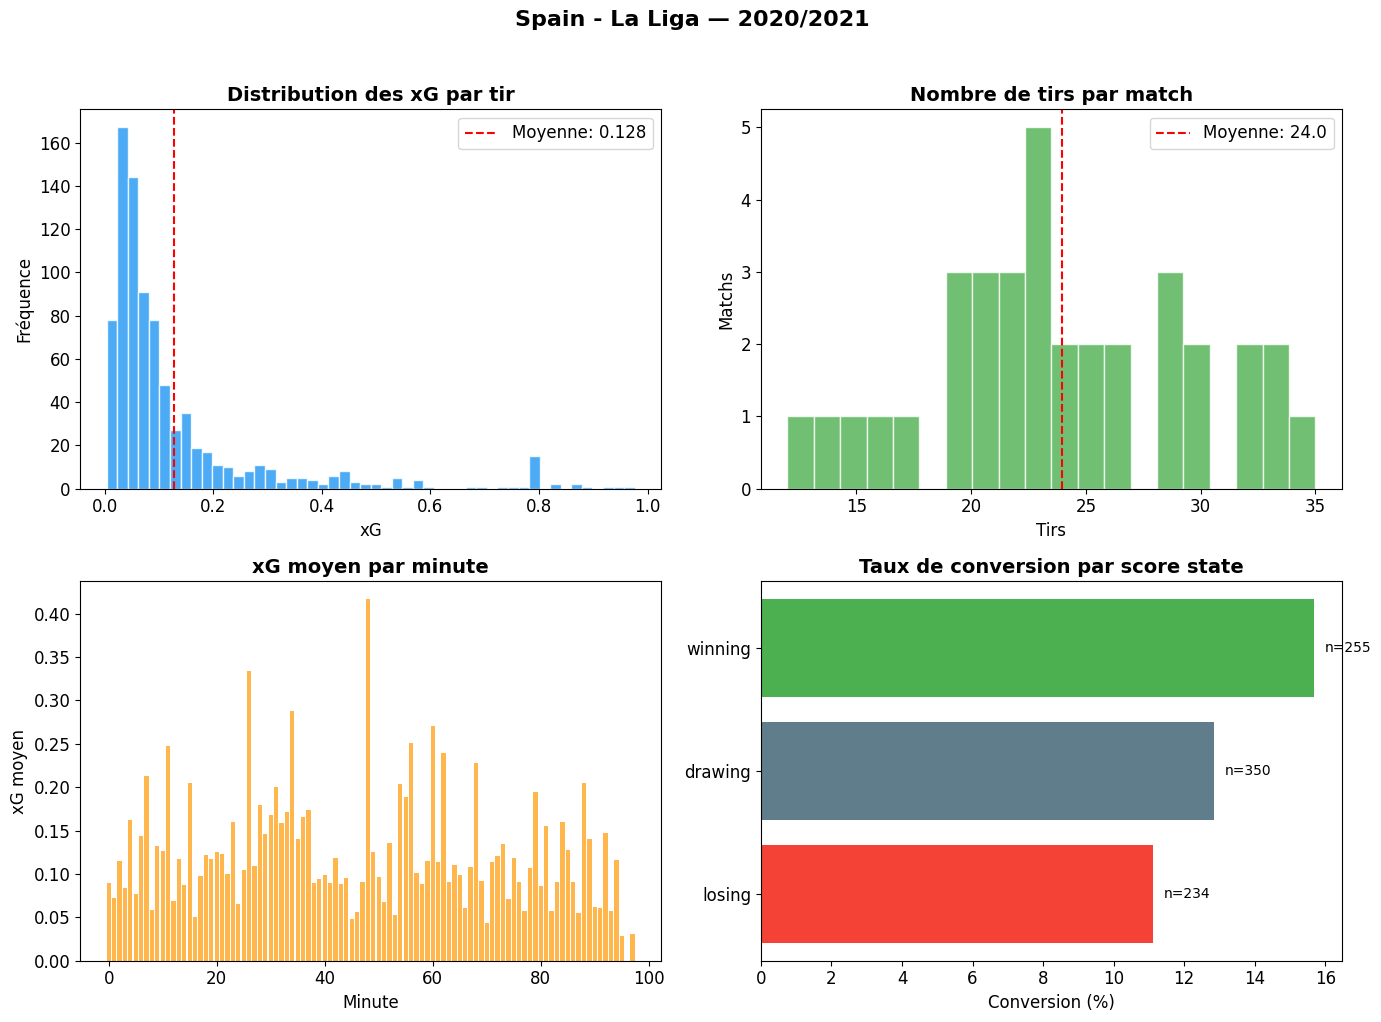

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Distribution des xG
axes[0, 0].hist(shots_clean['xg'], bins=50, color='#2196F3', 
                edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribution des xG par tir')
axes[0, 0].set_xlabel('xG')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(shots_clean['xg'].mean(), color='red', 
                    linestyle='--', label=f"Moyenne: {shots_clean['xg'].mean():.3f}")
axes[0, 0].legend()

# B. Tirs par match
shots_per_match = shots_clean.groupby('match_id').size()
axes[0, 1].hist(shots_per_match, bins=20, color='#4CAF50', 
                edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Nombre de tirs par match')
axes[0, 1].set_xlabel('Tirs')
axes[0, 1].set_ylabel('Matchs')
axes[0, 1].axvline(shots_per_match.mean(), color='red', 
                    linestyle='--', label=f"Moyenne: {shots_per_match.mean():.1f}")
axes[0, 1].legend()

# C. xG par minute du match
minute_xg = shots_clean.groupby(shots_clean['game_minute'].astype(int))['xg'].mean()
axes[1, 0].bar(minute_xg.index, minute_xg.values, color='#FF9800', alpha=0.7)
axes[1, 0].set_title('xG moyen par minute')
axes[1, 0].set_xlabel('Minute')
axes[1, 0].set_ylabel('xG moyen')

# D. Taux de conversion par score state
if 'score_state' in shots_clean.columns:
    conv_by_state = shots_clean.groupby('score_state')['is_goal'].agg(['mean', 'count'])
    conv_by_state = conv_by_state.sort_values('mean', ascending=True)
    colors = {'drawing': '#607D8B', 'losing': '#F44336', 'winning': '#4CAF50'}
    bar_colors = [colors.get(s, '#999') for s in conv_by_state.index]
    axes[1, 1].barh(conv_by_state.index, conv_by_state['mean'] * 100, color=bar_colors)
    axes[1, 1].set_title('Taux de conversion par score state')
    axes[1, 1].set_xlabel('Conversion (%)')
    for i, (idx, row) in enumerate(conv_by_state.iterrows()):
        axes[1, 1].text(row['mean'] * 100 + 0.3, i, 
                        f"n={int(row['count'])}", va='center', fontsize=10)

plt.suptitle(f"{shots_clean['competition_name'].iloc[0]} — {shots_clean['season_name'].iloc[0]}",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/01_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

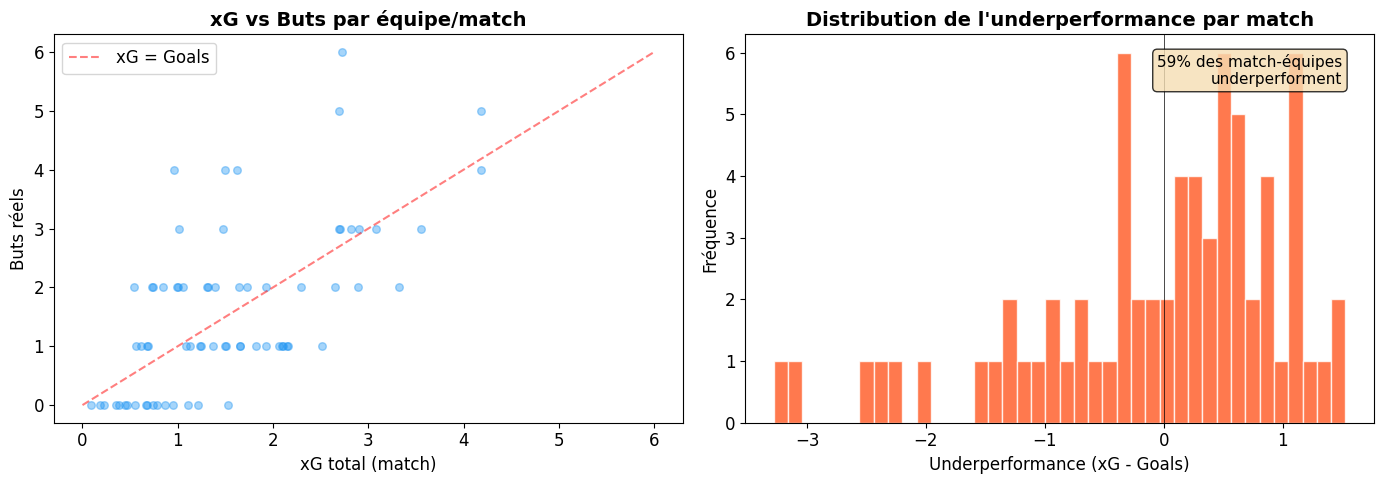

In [18]:
# Premier aperçu de l'underperformance : xG total vs buts par équipe et match
match_team_stats = shots_clean.groupby(['match_id', 'team']).agg(
    total_xg=('xg', 'sum'),
    total_goals=('is_goal', 'sum'),
    n_shots=('xg', 'count')
).reset_index()

match_team_stats['underperformance'] = match_team_stats['total_xg'] - match_team_stats['total_goals']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter xG vs Buts
axes[0].scatter(match_team_stats['total_xg'], match_team_stats['total_goals'],
                alpha=0.4, s=30, color='#2196F3')
max_val = max(match_team_stats['total_xg'].max(), match_team_stats['total_goals'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='xG = Goals')
axes[0].set_xlabel('xG total (match)')
axes[0].set_ylabel('Buts réels')
axes[0].set_title('xG vs Buts par équipe/match')
axes[0].legend()

# Distribution de l'underperformance
axes[1].hist(match_team_stats['underperformance'], bins=40, 
             color='#FF5722', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Underperformance (xG - Goals)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution de l\'underperformance par match')

pct_under = (match_team_stats['underperformance'] > 0).mean() * 100
axes[1].annotate(f"{pct_under:.0f}% des match-équipes\nunderperforment",
                 xy=(0.95, 0.95), xycoords='axes fraction',
                 ha='right', va='top', fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../outputs/figures/01_underperformance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Sauvegarder le dataset propre

In [19]:
# Sauvegarder en parquet (format efficace)
output_path = '../data/processed/shots_clean.parquet'
shots_clean.to_parquet(output_path, index=False)
print(f"✓ Dataset sauvegardé : {output_path}")
print(f"  Taille : {shots_clean.shape}")
print(f"  Matchs : {shots_clean['match_id'].nunique()}")
print(f"  Tirs   : {len(shots_clean)}")

✓ Dataset sauvegardé : ../data/processed/shots_clean.parquet
  Taille : (839, 26)
  Matchs : 35
  Tirs   : 839


---
## 8. Résumé & prochaines étapes

### Ce qu'on a fait :
- [x] Vérifié que StatsBomb fonctionne
- [x] Collecté une saison complète
- [x] Nettoyé et validé les données
- [x] Sauvegardé `shots_clean.parquet`

### Prochaine étape : Phase 2 — Feature Engineering
- Construire les timelines minute-par-minute
- Calculer le xG cumulé et l'underperformance
- Calculer les fenêtres futures (xGA, buts encaissés)

→ Ouvrir `02_feature_engineering.ipynb`